<a href="https://colab.research.google.com/github/akanksha1723/AI_Projects/blob/main/Day12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


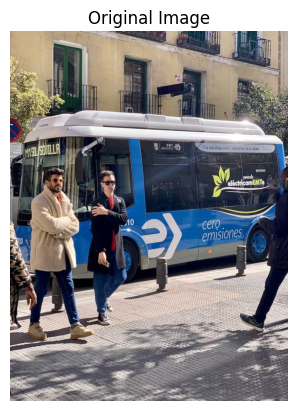

In [ ]:
image_url = 'https://ultralytics.com/images/bus.jpg'
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()


0: 640x480 4 persons, 1 bus, 1 stop sign, 369.6ms
Speed: 38.3ms preprocess, 369.6ms inference, 44.9ms postprocess per image at shape (1, 3, 640, 480)


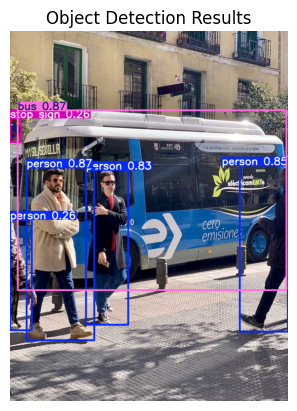

In [ ]:
results = model(image)
for r in results:
    im_array = r.plot()
    im = Image.fromarray(im_array[..., ::-1])
    plt.imshow(im)
    plt.title("Object Detection Results")
    plt.axis("off")
    plt.show()

In [ ]:
results[0].save('yolo_detection_results.jpg')
print("Detection results saved to 'yolo_detection_results.jpg' in the current working directory.")

Detection results saved to 'yolo_detection_results.jpg' in the current working directory.


In [ ]:
import cv2
import numpy as np

In [ ]:
class_names = model.names

In [ ]:
person_class_id = None
for class_id, class_name in class_names.items():
    if class_name == 'person':
        person_class_id = class_id
        break
if person_class_id is not None:
  print(f"Class ID for 'person': {person_class_id}")
else:
  print("Class 'person' not found in the model's classes.")

Class ID for 'person': 0


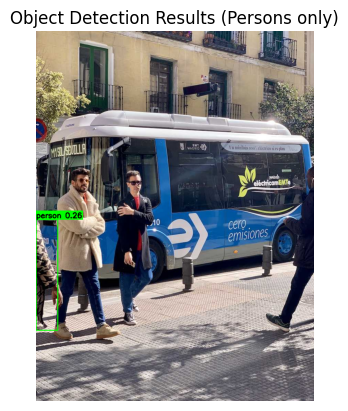

In [ ]:
if person_class_id is not None:
  imp_np = np.array(image)
  img_bgr = cv2.cvtColor(imp_np, cv2.COLOR_RGB2BGR)
  detections = results[0]
  person_detections = detections.boxes[detections.boxes.cls == person_class_id]
  for box in person_detections:
      x1, y1, x2, y2 = map(int,box.xyxy[0])
      conf = box.conf[0].item()
      cls = int(box.cls[0].item())

      class_name_for_box = class_names[cls]
  color = (0, 255, 0)
  thickness = 2
  cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, thickness)
  label = f"{class_name_for_box} {conf:.2f}"
  font = cv2.FONT_HERSHEY_SIMPLEX
  font_scale = 0.7
  font_thickness = 2
  text_size = cv2.getTextSize(label, font, font_scale, font_thickness)[0]
  cv2.rectangle(img_bgr, (x1, y1 - text_size[1] - 10), (x1 + text_size[0], y1), color, -1)
  cv2.putText(img_bgr, label, (x1, y1 - 5), font, font_scale, (0, 0, 0), font_thickness)
  im_filtered_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  im_filtered = Image.fromarray(im_filtered_rgb)
  plt.imshow(im_filtered)
  plt.title("Object Detection Results (Persons only)")
  plt.axis("off")
  plt.show()
else:
  print("Cannot filter by 'person' as its class ID was not found or an error occured." )